# PyMCBART Draft and Examples

## Data encoding for BART

In [1]:
import joblib
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# Load label encoder
label_encoder = joblib.load('/mnt/isilon/hayeckteam/cnv_project/scoring/cnv-modeling/data/modeling_train_test_v3.4/label_encoders.pkl')
print("Label encoders loaded:")
for var, encoder in label_encoder.items():
    print(f"  {var}: {list(encoder.classes_)}")

# Define call set directories
call_set_dirs = [
    Path('/mnt/isilon/hayeckteam/cnv_project/call-sets') / callset / 'merged_v2.5' for callset in [
        'MONTREAL',
        'TNT_conifer',
        'TNT_cn.mops',
        'HayeckTeam',
        'XHMM-iWESv3'
    ]
]

# Define categorical variables that need encoding
categorical_vars = ['Male', 'AutoChr', 'common_cnv', 'superclass']

def transform_categorical_variables(df, label_encoders, categorical_vars):
    """Transform categorical variables using pre-trained label encoders"""
    df_transformed = df.copy()
    
    for var in categorical_vars:
        if var in df_transformed.columns and var in label_encoders:
            encoder = label_encoders[var]
            
            # Convert to string first to handle any dtype issues
            df_transformed[var] = df_transformed[var].astype(str)
            
            # Handle missing values
            df_transformed[var] = df_transformed[var].fillna('MISSING')
            
            # Handle unknown categories by mapping them to a default value
            unknown_mask = ~df_transformed[var].isin(encoder.classes_)
            if unknown_mask.any():
                print(f"  Warning: Found {unknown_mask.sum()} unknown categories in {var}")
                # Map unknown categories to 'UNKNOWN' if it exists in encoder classes
                if 'UNKNOWN' in encoder.classes_:
                    df_transformed.loc[unknown_mask, var] = 'UNKNOWN'
                elif 'MISSING' in encoder.classes_:
                    df_transformed.loc[unknown_mask, var] = 'MISSING'
                else:
                    # Use the most frequent class as default
                    default_class = encoder.classes_[0]
                    df_transformed.loc[unknown_mask, var] = default_class
                    print(f"  Mapped unknown categories to: {default_class}")
            
            # Transform using label encoder
            df_transformed[var] = encoder.transform(df_transformed[var])
            print(f"  Transformed {var}: {len(encoder.classes_)} categories")
    
    return df_transformed

def apply_onehot_encoding(df, categorical_vars, label_encoders):
    """Apply one-hot encoding to label-encoded categorical variables"""
    df_onehot = df.copy()
    
    for var in categorical_vars:
        if var in df_onehot.columns and var in label_encoders:
            encoder = label_encoders[var]
            
            # Get the label-encoded values
            label_values = df_onehot[var].values.reshape(-1, 1)
            
            # Create one-hot encoder
            onehot_encoder = OneHotEncoder(sparse_output=False, dtype=int)
            
            # Get all possible label values (0 to n_classes-1)
            all_labels = np.arange(len(encoder.classes_)).reshape(-1, 1)
            onehot_encoder.fit(all_labels)
            
            # Transform the data
            onehot_encoded = onehot_encoder.transform(label_values)
            
            # Create column names using label numbers + 1 (so they start from 1 instead of 0)
            onehot_columns = [f"{var}{i+1}" for i in range(len(encoder.classes_))]
            
            # Create DataFrame with one-hot encoded columns
            onehot_df = pd.DataFrame(onehot_encoded, columns=onehot_columns, index=df_onehot.index)
            
            # Add the new columns to the main dataframe
            df_onehot = pd.concat([df_onehot, onehot_df], axis=1)
            
            # Remove the original label-encoded column
            df_onehot = df_onehot.drop(columns=[var])
            
            print(f"  One-hot encoded {var}: {len(onehot_columns)} columns created")
            print(f"    Column names: {onehot_columns}")
    
    return df_onehot

# Process each call set directory
for call_set_dir in call_set_dirs:
    call_set_name = call_set_dir.parent.name
    print(f"\nProcessing call set: {call_set_name}")
    print(f"Directory: {call_set_dir}")
    
    if not call_set_dir.exists():
        print(f"  Directory not found, skipping...")
        continue
    
    # Find all parquet files
    parquet_files = list(call_set_dir.glob('*_merged.parquet'))
    print(f"  Found {len(parquet_files)} parquet files")
    
    for parquet_file in sorted(parquet_files):
        print(f"\n  Processing: {parquet_file.name}")
        
        try:
            # Load parquet file
            df = pd.read_parquet(parquet_file)
            print(f"    Original shape: {df.shape}")
            
            # Check which categorical variables exist in this dataset
            available_cats = [var for var in categorical_vars if var in df.columns]
            print(f"    Available categorical variables: {available_cats}")
            
            if not available_cats:
                print(f"    No categorical variables to transform, skipping...")
                continue
            
            # Step 1: Transform categorical variables using label encoders
            df_transformed = transform_categorical_variables(df, label_encoder, available_cats)
            
            # Step 2: Apply one-hot encoding to label-encoded variables
            print(f"    Applying one-hot encoding...")
            df_onehot = apply_onehot_encoding(df_transformed, available_cats, label_encoder)
            
            # Create output filename with _encoded_onehot suffix
            output_file = parquet_file.parent / f"{parquet_file.stem}_encoded_onehot.parquet"
            
            # Save transformed data
            df_onehot.to_parquet(output_file, index=False)
            print(f"    Saved to: {output_file.name}")
            print(f"    Final shape: {df_onehot.shape}")
            
            # Show sample of one-hot encoded columns
            print(f"    Sample of one-hot encoded columns:")
            for var in available_cats:
                onehot_cols = [col for col in df_onehot.columns if col.startswith(var)]
                if onehot_cols:
                    print(f"      {var} -> {len(onehot_cols)} columns: {onehot_cols}")
                    # Show a sample of the one-hot values for first few rows
                    sample_data = df_onehot[onehot_cols].head(3)
                    for idx, row in sample_data.iterrows():
                        active_cols = [col for col in onehot_cols if row[col] == 1]
                        print(f"        Row {idx}: active column = {active_cols}")
            
        except Exception as e:
            print(f"    Error processing {parquet_file.name}: {str(e)}")
            continue

print(f"\nCategorical variable transformation completed!")
print("Files with label encoding + one-hot encoding saved with '_encoded_onehot' suffix.")
print("Each categorical variable is now represented as multiple binary columns using label numbers + 1 as suffixes.")
print("Example: Label 0 of Male becomes Male1, Label 1 becomes Male2, etc.")

Label encoders loaded:
  Male: [np.str_('0'), np.str_('1')]
  AutoChr: [np.str_('0'), np.str_('1')]
  common_cnv: [np.str_('MISSING'), np.str_('None'), np.str_('neuro'), np.str_('non_neuro'), np.str_('non_neuro_control'), np.str_('not_reported')]
  superclass: [np.str_('AFR'), np.str_('AMR'), np.str_('EAS'), np.str_('EUR'), np.str_('SAS'), np.str_('UNKNOWN')]
  platform: [np.str_('cnmops'), np.str_('conifer'), np.str_('spotr'), np.str_('xhmm')]

Processing call set: MONTREAL
Directory: /mnt/isilon/hayeckteam/cnv_project/call-sets/MONTREAL/merged_v2.5
  Found 4 parquet files

  Processing: wes1_merged.parquet
    Original shape: (68297, 103)
    Available categorical variables: ['Male', 'AutoChr', 'common_cnv', 'superclass']
  Transformed Male: 2 categories
  Transformed AutoChr: 2 categories
  Transformed common_cnv: 6 categories
    Original shape: (68297, 103)
    Available categorical variables: ['Male', 'AutoChr', 'common_cnv', 'superclass']
  Transformed Male: 2 categories
  Trans

: 

In [ ]:
# Verification function to show the mapping between original categories and one-hot columns
def show_encoding_mapping(label_encoders, categorical_vars):
    """Show the mapping between original categories, label numbers, and one-hot column names"""
    print("Encoding Mapping Summary:")
    print("=" * 80)
    
    for var in categorical_vars:
        if var in label_encoders:
            encoder = label_encoders[var]
            print(f"\nVariable: {var}")
            print(f"Original Categories -> Label -> One-hot Column")
            print("-" * 50)
            
            for label, category in enumerate(encoder.classes_):
                onehot_col = f"{var}{label+1}"  # Add 1 to label number
                print(f"{category:>15} -> {label:>5} -> {onehot_col}")
    
    print("=" * 80)

# Show the mapping for reference
show_encoding_mapping(label_encoder, categorical_vars)

NameError: name 'categorical_vars' is not defined

In [3]:
import joblib
from pathlib import Path
import pandas as pd

# Load label encoder
label_encoder = joblib.load('/mnt/isilon/hayeckteam/cnv_project/scoring/cnv-modeling/data/modeling_train_test_v3.4/label_encoders.pkl')

type(label_encoder)

dict

In [9]:
label_encoder['common_cnv'].classes_

array(['MISSING', 'None', 'neuro', 'non_neuro', 'non_neuro_control',
       'not_reported'], dtype='<U17')

## Test code on the CNV project

In [ ]:
import pymc as pm
import pymc_bart as pmb
import arviz as az

import pandas as pd
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import argparse
import time
import joblib
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

parser = argparse.ArgumentParser()
parser.add_argument('--cnv_status', type=str, required=True)
parser.add_argument('--data_dir', type=str, required=True)
parser.add_argument('--save_dir', type=str, required=True)

def preprocess_data(X_train, X_test, categorical_cols, cats_2drop):
    """Preprocess data for BART model using LabelEncoder and handle missing values"""
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Remove additional columns
    for col in cats_2drop:
        if col in X_train_processed.columns:
            X_train_processed = X_train_processed.drop(columns=col)
        if col in X_test_processed.columns:
            X_test_processed = X_test_processed.drop(columns=col)

    # Column definitions
    row_key_cols = ['ID', 'Chrom', 'Start', 'End', 'cnvStatus']
    yvar = 'Groundtruth'
    cols_2exclude = row_key_cols + [yvar, 'source', 'orig_label']

    # Remove some columns
    for col in cols_2exclude:
        if col in X_train_processed.columns:
            X_train_processed = X_train_processed.drop(columns=col)
        if col in X_test_processed.columns:
            X_test_processed = X_test_processed.drop(columns=col)

    # Check for missing values before processing
    print("Checking for missing values...")
    train_missing = X_train_processed.isnull().sum()
    test_missing = X_test_processed.isnull().sum()
    
    if train_missing.sum() > 0:
        print("Missing values in training data:")
        print(train_missing[train_missing > 0])
        
    if test_missing.sum() > 0:
        print("Missing values in test data:")
        print(test_missing[test_missing > 0])

    # Use LabelEncoder for categorical variables
    label_encoders = {}
    for col in categorical_cols:
        if col in X_train_processed.columns:
            le = LabelEncoder()
            
            # Convert categorical columns to string type first to avoid categorical dtype issues
            if X_train_processed[col].dtype.name == 'category':
                X_train_processed[col] = X_train_processed[col].astype(str)
            if X_test_processed[col].dtype.name == 'category':
                X_test_processed[col] = X_test_processed[col].astype(str)
            
            # Combine train and test data to fit encoder on all possible categories
            combined_data = pd.concat([X_train_processed[col], X_test_processed[col]], axis=0)
            combined_data = combined_data.dropna()  # Remove NaN values
            
            # Fit the encoder on combined data
            le.fit(combined_data)
            
            # Handle missing values by filling with a default category before encoding
            X_train_processed[col] = X_train_processed[col].fillna('MISSING')
            X_test_processed[col] = X_test_processed[col].fillna('MISSING')
            
            # Add 'MISSING' to the encoder if it wasn't in the original data
            if 'MISSING' not in le.classes_:
                # Create a new encoder that includes 'MISSING'
                all_categories = list(le.classes_) + ['MISSING']
                le = LabelEncoder()
                le.fit(all_categories)
            
            # Transform both train and test data
            X_train_processed[col] = le.transform(X_train_processed[col])
            X_test_processed[col] = le.transform(X_test_processed[col])
            
            # Store the encoder for later use if needed
            label_encoders[col] = le
            
            print(f"Encoded '{col}': {dict(zip(le.classes_, range(len(le.classes_))))}")

    # Handle missing values in numeric columns
    numeric_cols = X_train_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if X_train_processed[col].isnull().any() or X_test_processed[col].isnull().any():
            # Use a constant value outside the normal range
            fill_value = -99
            X_train_processed[col] = X_train_processed[col].fillna(fill_value)
            X_test_processed[col] = X_test_processed[col].fillna(fill_value)
            print(f"Filled missing values in '{col}' with constant: {fill_value}")

    # Final check for any remaining missing values
    print("\nFinal missing value check:")
    final_train_missing = X_train_processed.isnull().sum().sum()
    final_test_missing = X_test_processed.isnull().sum().sum()
    
    print(f"Training data missing values: {final_train_missing}")
    print(f"Test data missing values: {final_test_missing}")
    
    if final_train_missing > 0 or final_test_missing > 0:
        raise ValueError("There are still missing values after preprocessing")

    return X_train_processed, X_test_processed, label_encoders

def train_bart_model(X_train, y_train, X_test, y_test, 
                     save_dir, save_suffix, save_data=False, 
                     num_trees=100, draws=1000, tune=1000, chains=2, 
                     cores=1, threshold=0.5, seed=42):
    """Train BART model using PyMC"""
    
    print(f"Training BART model for {save_suffix}")
    print(f"Training data shape: {X_train.shape}")
    print(f"Class distribution: {y_train.value_counts().to_dict()}")
    
    # Ensure no missing values before creating pm.Data
    if X_train.isnull().any().any():
        raise ValueError("Training data still contains missing values!")
    if X_test.isnull().any().any():
        raise ValueError("Test data still contains missing values!")
        
    # Build BART model
    with pm.Model() as bart_model:
        X = pm.Data("X", X_train)
        Y = pm.Data("Y", y_train)

        # BART prior for the mean
        mu = pmb.BART("mu", X=X, Y=Y, m=num_trees)
        
        # Bernoulli likelihood for binary classification
        # p = pm.Deterministic("p", pm.math.sigmoid(mu))
        # y_obs = pm.Bernoulli("y_obs", p=mu, observed=y_train)
        y_obs = pm.Bernoulli("y_obs", logit_p=mu, observed=y_train)
        
        # Sample from posterior
        print("Sampling from posterior...")
        start_time = time.time()
        
        # Use single core for BART sampling to avoid multiprocessing issues
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=1,  # Force single core to avoid ConnectionResetError
            random_seed=seed,
            progressbar=True,
            return_inferencedata=True
        )
        
        sampling_time = time.time() - start_time
        print(f"Sampling completed in {sampling_time:.2f} seconds")
    
    # Make predictions on test set
    print("Making predictions on test set...")
    with bart_model:
        # Posterior predictions
        pm.set_data({"X": X_test})
        posterior_pred = pm.sample_posterior_predictive(
            idata, 
            var_names=["y_obs"],
            progressbar=True
        )
    
    # Extract predictions
    pred_samples = posterior_pred.posterior_predictive["y_obs"].values
    pred_mean = pred_samples.mean(axis=(0, 1))
    pred_std = pred_samples.std(axis=(0, 1))
    
    # Convert to binary predictions
    pred_binary = (pred_mean > threshold).astype(int)
    
    # Calculate metrics
    roc_auc = metrics.roc_auc_score(y_test, pred_mean)
    accuracy = metrics.accuracy_score(y_test, pred_binary)
    balanced_acc = metrics.balanced_accuracy_score(y_test, pred_binary)
    
    print("Model Performance:")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    
    # Save model and results
    results = {
        'idata': idata,
        'posterior_pred': posterior_pred,
        'pred_mean': pred_mean,
        'pred_std': pred_std,
        'pred_binary': pred_binary,
        'metrics': {
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'balanced_accuracy': balanced_acc
        },
        'feature_names': X_train.columns.tolist(),
        'model_config': {
            'draws': draws,
            'tune': tune,
            'chains': chains,
            'cores': cores,
            'm': num_trees  # number of trees
        }
    }
    
    if save_data:
        # Save inference data
        idata.to_netcdf(save_dir / f"bart_{save_suffix}_idata.nc")
        
        # Save results as pickle
        joblib.dump(results, save_dir / f"bart_{save_suffix}_results.pkl")
    
    return results, bart_model

def create_diagnostic_plots(results, save_dir, save_suffix):
    """Create diagnostic plots for BART model"""
    
    idata = results['idata']
    pred_mean = results['pred_mean']
    pred_std = results['pred_std']
    
    # Set up the plotting style
    az.style.use("arviz-darkgrid")
    
    # 1. Trace plots
    print("Creating trace plots...")
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    az.plot_trace(idata, var_names=["mu"], axes=axes)
    plt.suptitle(f'BART Trace Plots - {save_suffix.upper()}')
    plt.tight_layout()
    plt.savefig(save_dir / f"bart_{save_suffix}_trace.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # 2. Energy plot
    print("Creating energy plot...")
    fig, ax = plt.subplots(figsize=(8, 6))
    az.plot_energy(idata, ax=ax)
    plt.title(f'Energy Plot - {save_suffix.upper()}')
    plt.savefig(save_dir / f"bart_{save_suffix}_energy.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # 3. Rank plots
    print("Creating rank plots...")
    fig, ax = plt.subplots(figsize=(10, 6))
    az.plot_rank(idata, var_names=["mu"], ax=ax)
    plt.title(f'Rank Plot - {save_suffix.upper()}')
    plt.savefig(save_dir / f"bart_{save_suffix}_rank.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # 4. Forest plot (if we have multiple chains)
    try:
        print("Creating forest plot...")
        fig, ax = plt.subplots(figsize=(8, 6))
        az.plot_forest(idata, var_names=["mu"], combined=True, ax=ax)
        plt.title(f'Forest Plot - {save_suffix.upper()}')
        plt.savefig(save_dir / f"bart_{save_suffix}_forest.png", dpi=300, bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"Could not create forest plot: {e}")
    
    # 5. Prediction uncertainty plot
    print("Creating prediction uncertainty plot...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Mean predictions
    ax1.hist(pred_mean, bins=30, alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Predicted Probability')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Prediction Distribution - {save_suffix.upper()}')
    ax1.axvline(0.5, color='red', linestyle='--', label='Decision Threshold')
    ax1.legend()
    
    # Prediction uncertainty
    ax2.scatter(pred_mean, pred_std, alpha=0.6)
    ax2.set_xlabel('Predicted Probability')
    ax2.set_ylabel('Prediction Uncertainty (Std)')
    ax2.set_title(f'Prediction Uncertainty - {save_suffix.upper()}')
    
    plt.tight_layout()
    plt.savefig(save_dir / f"bart_{save_suffix}_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # 6. Posterior predictive check
    try:
        print("Creating posterior predictive check...")
        fig, ax = plt.subplots(figsize=(8, 6))
        az.plot_ppc(results['posterior_pred'], group="posterior_predictive", ax=ax)
        plt.title(f'Posterior Predictive Check - {save_suffix.upper()}')
        plt.savefig(save_dir / f"bart_{save_suffix}_ppc.png", dpi=300, bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"Could not create posterior predictive check: {e}")

def create_performance_plots(y_true, pred_mean, pred_binary, save_dir, save_suffix):
    """Create performance evaluation plots"""
    
    # 1. Prediction histogram by true class
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Separate predictions by ground truth labels
    pred_true = pred_mean[y_true == 1]
    pred_false = pred_mean[y_true == 0]
    
    # Create overlaid histograms
    ax.hist(pred_false, bins=30, alpha=0.7, color='red', edgecolor='black', label='False')
    ax.hist(pred_true, bins=30, alpha=0.7, color='blue', edgecolor='black', label='True')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Prediction Distribution by True Class - {save_suffix.upper()}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"bart_{save_suffix}_pred_hist.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # 2. Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_true, pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['False', 'True'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title(f'Confusion Matrix - {save_suffix.upper()}')
    plt.savefig(save_dir / f"bart_{save_suffix}_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # 3. ROC Curve
    fig, ax = plt.subplots(figsize=(8, 6))
    fpr, tpr, _ = metrics.roc_curve(y_true, pred_mean)
    roc_auc = metrics.auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {save_suffix.upper()}')
    ax.legend(loc="lower right")
    plt.savefig(save_dir / f"bart_{save_suffix}_roc.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # 4. Precision-Recall Curve
    fig, ax = plt.subplots(figsize=(8, 6))
    precision, recall, _ = metrics.precision_recall_curve(y_true, pred_mean)
    pr_auc = metrics.auc(recall, precision)
    
    ax.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve - {save_suffix.upper()}')
    ax.legend()
    plt.savefig(save_dir / f"bart_{save_suffix}_pr.png", dpi=300, bbox_inches='tight')
    plt.close()

In [11]:
print('LAUNCH BART modeling')

###### Configuration -----
data_dir = '/mnt/isilon/hayeckteam/cnv_project/scoring/cnv-modeling/data/modeling_train_test_v2.8.1'
save_dir = '/mnt/isilon/hayeckteam/cnv_project/scoring/cnv-modeling/results/bart_tests'
cnv_status = 'del'

seed = 250910
num_trees = 100
draws = 1000
tune = 1000

max_cores = os.cpu_count()
chains = min(4, max_cores)
cores = 1  # Use single core for BART to avoid multiprocessing issues
print(f"Using {chains} chains on {cores} core (avoiding multiprocessing issues)")

threshold = 0.5

# Load data
data_dir = Path(data_dir)
X_train = pd.read_parquet(data_dir / f'{cnv_status}_X_train.parquet')
X_test = pd.read_parquet(data_dir / f'{cnv_status}_X_test.parquet')

y_train = pd.read_parquet(data_dir / f'{cnv_status}_y_train.parquet')
y_test = pd.read_parquet(data_dir / f'{cnv_status}_y_test.parquet')

# Create save directory
save_dir = Path(save_dir)
save_dir.mkdir(parents=True, exist_ok=True)

# Categorical variables
xvar_cat = ['Male', 'AutoChr', 'common_cnv', 'superclass']
cats_2drop = ['kmeans', 'platform']

# Update categorical variables list
xvar_cat = [col for col in xvar_cat if col in X_train.columns and col in X_test.columns]

print(f"Features: {X_train.columns.tolist()}")
    
# Preprocess data using LabelEncoder
print("Preprocessing data with LabelEncoder...")
X_train_processed, X_test_processed, encoders = preprocess_data(X_train, X_test, xvar_cat, cats_2drop)

print(f"Processed features: {X_train_processed.columns.tolist()}")
print(f"Label encoders created for: {list(encoders.keys())}")

# Train BART model
print("Training BART model...")
results, model = train_bart_model(
    X_train_processed, y_train, X_test_processed, y_test,
    save_dir, cnv_status, 
    num_trees, draws, tune, chains, cores, seed
)

LAUNCH BART modeling
Using 4 chains on 4 cores (max available: 4)
Features: ['Average_RPKM1', 'Average_FPKM1', 'Average_normRPKM1', 'Average_normFPKM1', 'Average_PC_Adj1', 'Average_PC_Adj3', 'Average_PC_Adj5', 'Average_PC_Adj10', 'Average_PC_Adj20', 'Median_RPKM1', 'Median_FPKM1', 'Median_normRPKM1', 'Median_normFPKM1', 'Median_PC_Adj1', 'Median_PC_Adj3', 'Median_PC_Adj5', 'Median_PC_Adj10', 'Median_PC_Adj20', 'skew_RPKM1', 'skew_FPKM1', 'skew_normRPKM1', 'skew_normFPKM1', 'skew_PC_Adj1', 'skew_PC_Adj3', 'skew_PC_Adj5', 'skew_PC_Adj10', 'skew_PC_Adj20', 'kurtosis_RPKM1', 'kurtosis_FPKM1', 'kurtosis_normRPKM1', 'kurtosis_normFPKM1', 'kurtosis_PC_Adj1', 'kurtosis_PC_Adj3', 'kurtosis_PC_Adj5', 'kurtosis_PC_Adj10', 'kurtosis_PC_Adj20', 'num_modes_RPKM1', 'num_modes_FPKM1', 'num_modes_normRPKM1', 'num_modes_normFPKM1', 'num_modes_PC_Adj1', 'num_modes_PC_Adj3', 'num_modes_PC_Adj5', 'num_modes_PC_Adj10', 'num_modes_PC_Adj20', 'AndersonDarling_RPKM1', 'AndersonDarling_FPKM1', 'AndersonDarling_

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [mu]
PGBART: [mu]


Output()

ConnectionResetError: [Errno 104] Connection reset by peer

In [ ]:
# Create diagnostic plots
print("Creating diagnostic plots...")
create_diagnostic_plots(results, save_dir, cnv_status)

In [ ]:
# Create performance plots
print("Creating performance plots...")
create_performance_plots(
    y_test.values.flatten(), 
    results['pred_mean'], 
    results['pred_binary'],
    save_dir, 
    cnv_status
)

# Print summary
print("\n" + "="*50)
print("BART MODEL SUMMARY")
print("="*50)
print(f"CNV Status: {cnv_status}")
print(f"Training samples: {len(X_train_processed)}")
print(f"Test samples: {len(X_test_processed)}")
print(f"Features: {len(X_train_processed.columns)}")
print(f"ROC AUC: {results['metrics']['roc_auc']:.4f}")
print(f"Accuracy: {results['metrics']['accuracy']:.4f}")
print(f"Balanced Accuracy: {results['metrics']['balanced_accuracy']:.4f}")
print(f"Results saved to: {save_dir}")
print("="*50)

In [20]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the dataset
cancer_data = load_breast_cancer()

# Access features and target
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = pd.DataFrame(cancer_data.target, columns=['Groundtruth'])

## Example 1 (univariate data)

In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb

from sklearn.model_selection import train_test_split

%config InlineBackend.figure_format = "retina"

RANDOM_SEED = 5781
np.random.seed(RANDOM_SEED)
az.style.use("arviz-darkgrid")

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.23.0


In [2]:
size = 200
X = np.random.rand(size, 2) * 10
true_prob = 1 / (1 + np.exp(-(X[:, 0] - 5 + 2 * X[:, 1] - 8)))  # Sigmoid function for probability
Y = np.random.binomial(n=1, p=true_prob, size=size)

In [3]:
Y

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1])

In [4]:
try:
    coal = np.loadtxt(Path("..", "data", "coal.csv"))
except FileNotFoundError:
    coal = np.loadtxt(pm.get_data("coal.csv"))

In [5]:
coal.shape

(191,)

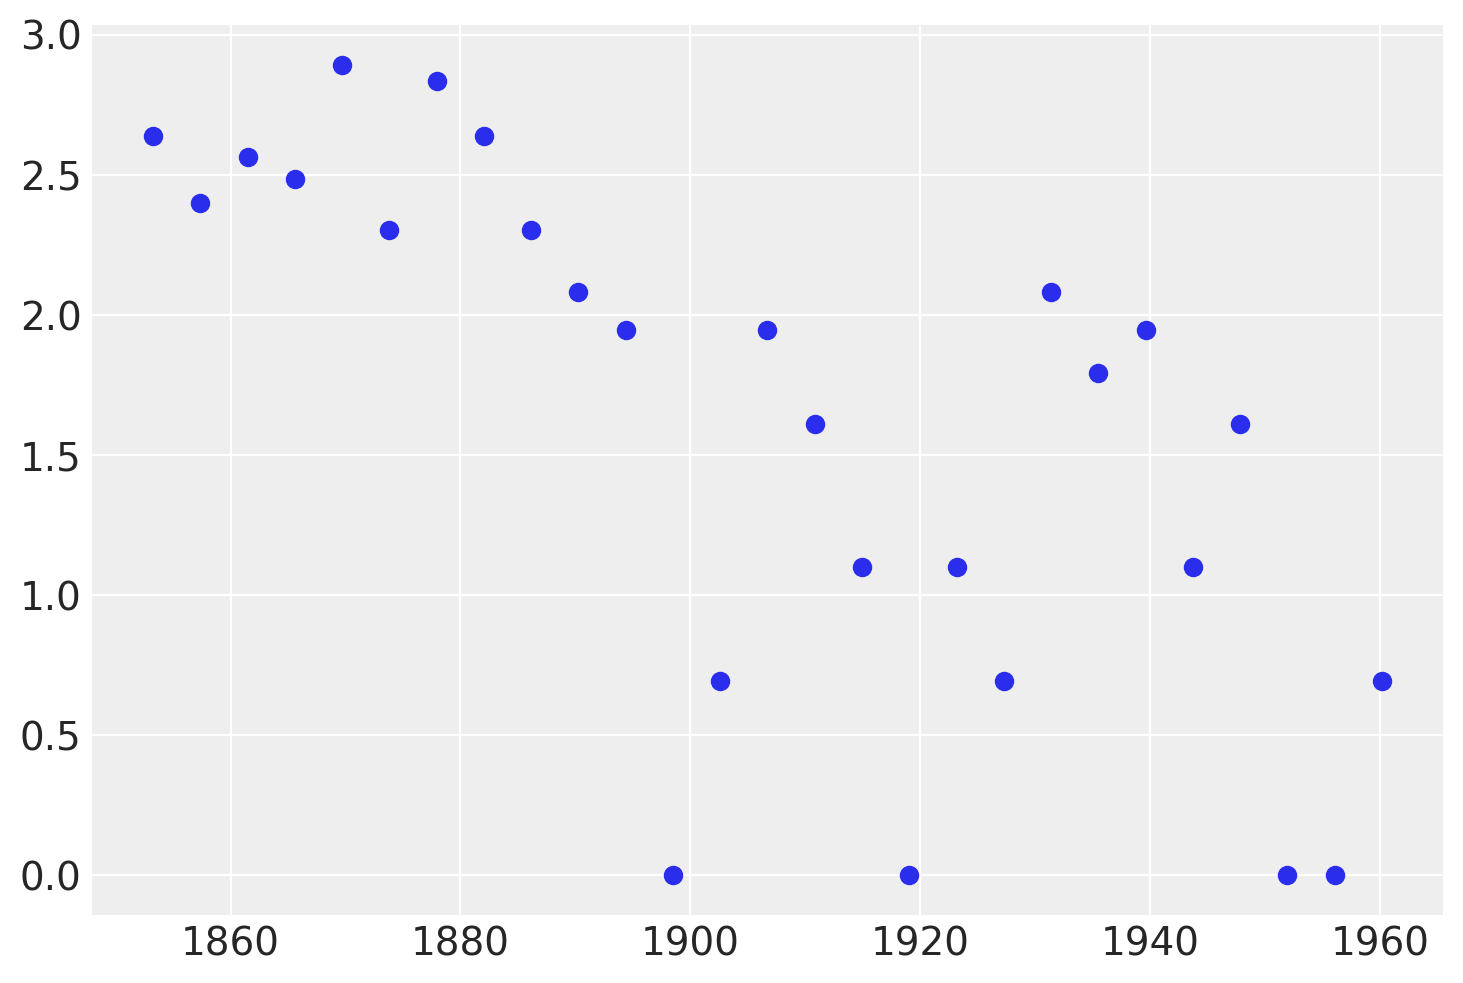

In [6]:
# discretize data
years = int(coal.max() - coal.min())
bins = years // 4
hist, x_edges = np.histogram(coal, bins=bins)
# compute the location of the centers of the discretized data
x_centers = x_edges[:-1] + (x_edges[1] - x_edges[0]) / 2
# xdata needs to be 2D for BART
x_data = x_centers[:, None]
# express data as the rate number of disaster per year
y_data = hist

plt.plot(x_centers, np.log(y_data), "o")

In [7]:
with pm.Model() as model_coal:
    μ_ = pmb.BART("μ_", X=x_data, Y=np.log(y_data), m=20)
    μ = pm.Deterministic("μ", pm.math.exp(μ_))
    y_pred = pm.Poisson("y_pred", mu=μ, observed=y_data)
    idata_coal = pm.sample(random_seed=RANDOM_SEED, cores=1)

Sequential sampling (2 chains in 1 job)
PGBART: [μ_]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 21 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [8]:
idata_coal

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [9]:
(idata_coal.posterior["μ"]/4).shape

(2, 1000, 27)

Text(0, 0.5, 'rate')

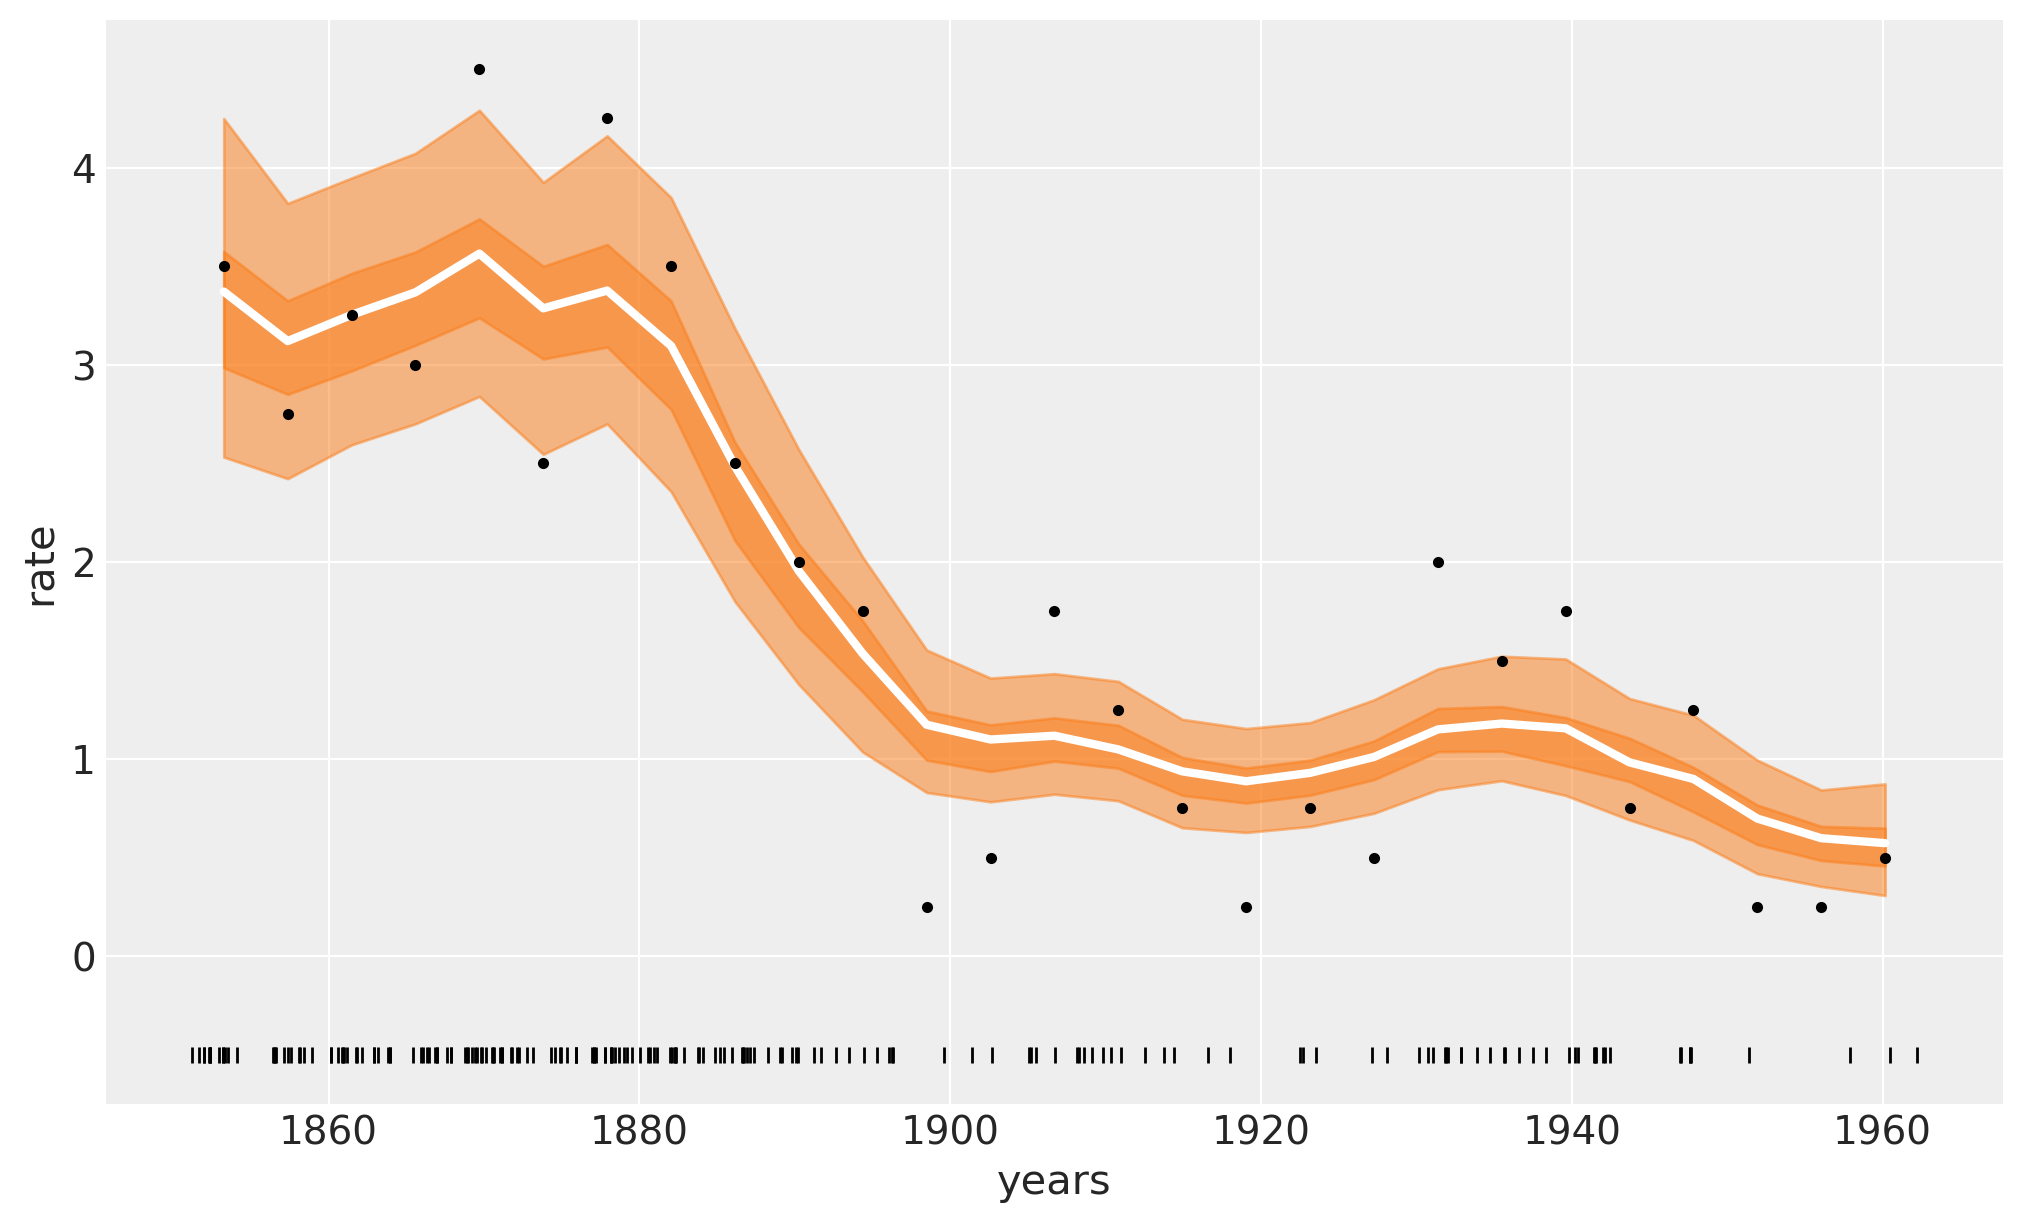

In [10]:
_, ax = plt.subplots(figsize=(10, 6))

rates = idata_coal.posterior["μ"] / 4
rate_mean = rates.mean(dim=["draw", "chain"])
ax.plot(x_centers, rate_mean, "w", lw=3)
ax.plot(x_centers, y_data / 4, "k.")
az.plot_hdi(x_centers, rates, smooth=False)
az.plot_hdi(x_centers, rates, hdi_prob=0.5, smooth=False, plot_kwargs={"alpha": 0})
ax.plot(coal, np.zeros_like(coal) - 0.5, "k|")
ax.set_xlabel("years")
ax.set_ylabel("rate")

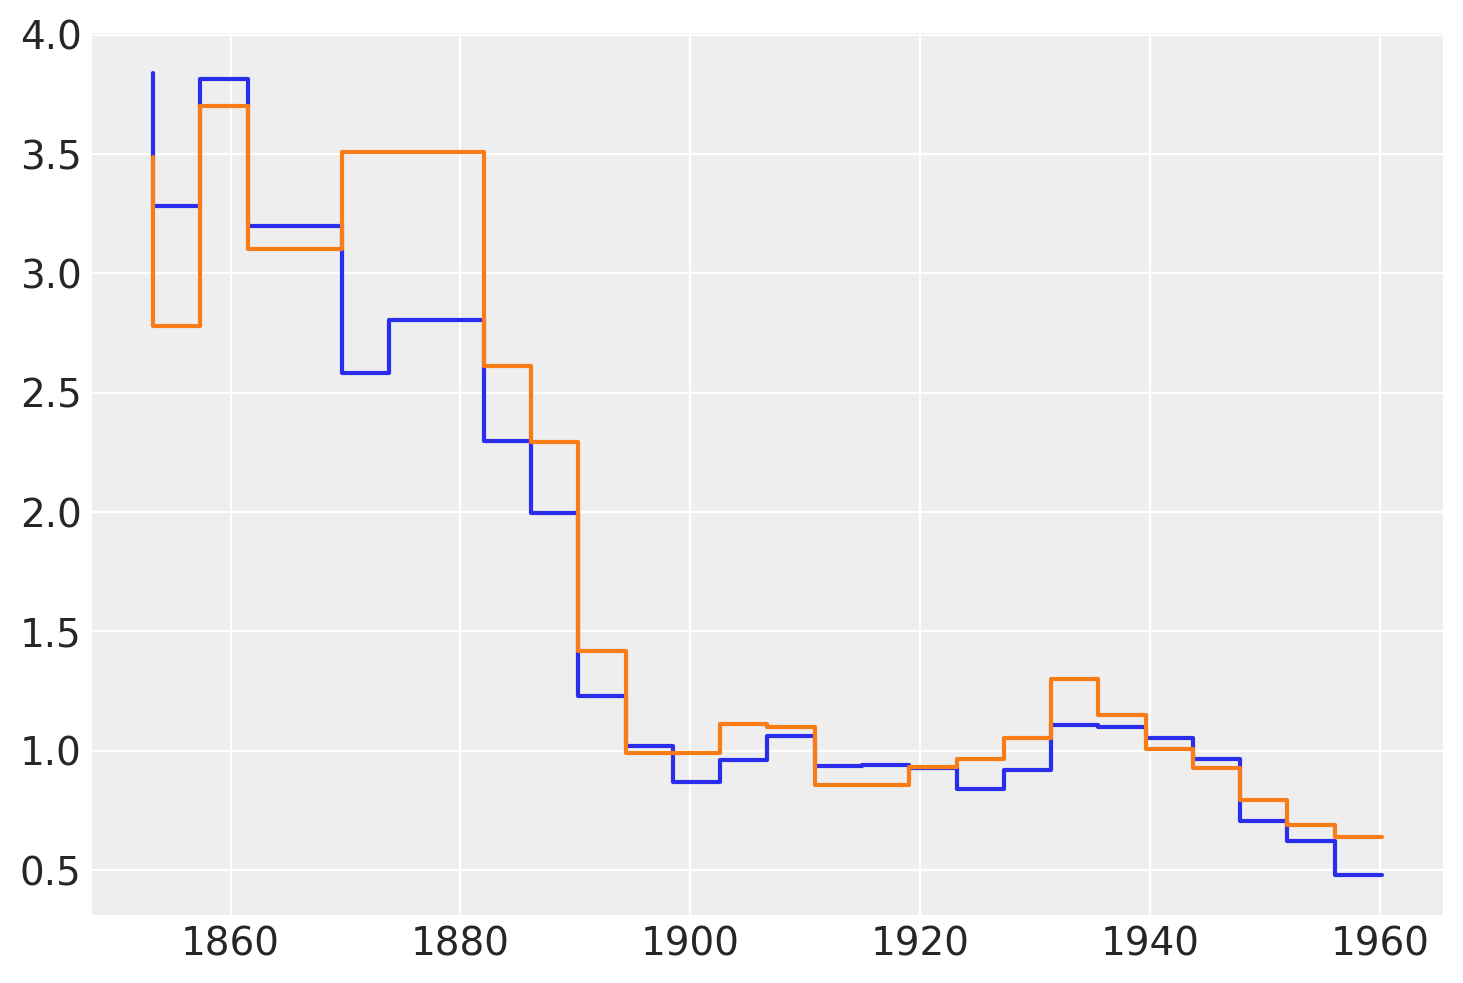

In [11]:
plt.step(x_data, rates.sel(chain=0, draw=[3, 10]).T)

## Example 2 (multivariate data)

In [12]:
try:
    bikes = pd.read_csv(Path("..", "data", "bikes.csv"))
except FileNotFoundError:
    bikes = pd.read_csv(pm.get_data("bikes.csv"))

features = ["hour", "temperature", "humidity", "workingday"]

X = bikes[features]
Y = bikes["count"]

In [13]:
type(Y)

pandas.core.series.Series

In [14]:
bikes.dtypes

count            int64
hour             int64
temperature    float64
humidity       float64
workingday       int64
dtype: object

In [15]:
with pm.Model() as model_bikes:
    α = pm.Exponential("α", 1)
    μ = pmb.BART("μ", X, np.log(Y), m=50)
    y = pm.NegativeBinomial("y", mu=pm.math.exp(μ), alpha=α, observed=Y)
    idata_bikes = pm.sample(compute_convergence_checks=False, random_seed=RANDOM_SEED, cores=1)

Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [α]
>PGBART: [μ]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 79 seconds.


### Convergence diagnostics and model checking

array([[<Axes: title={'center': 'α'}>,
        <Axes: title={'center': 'α'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

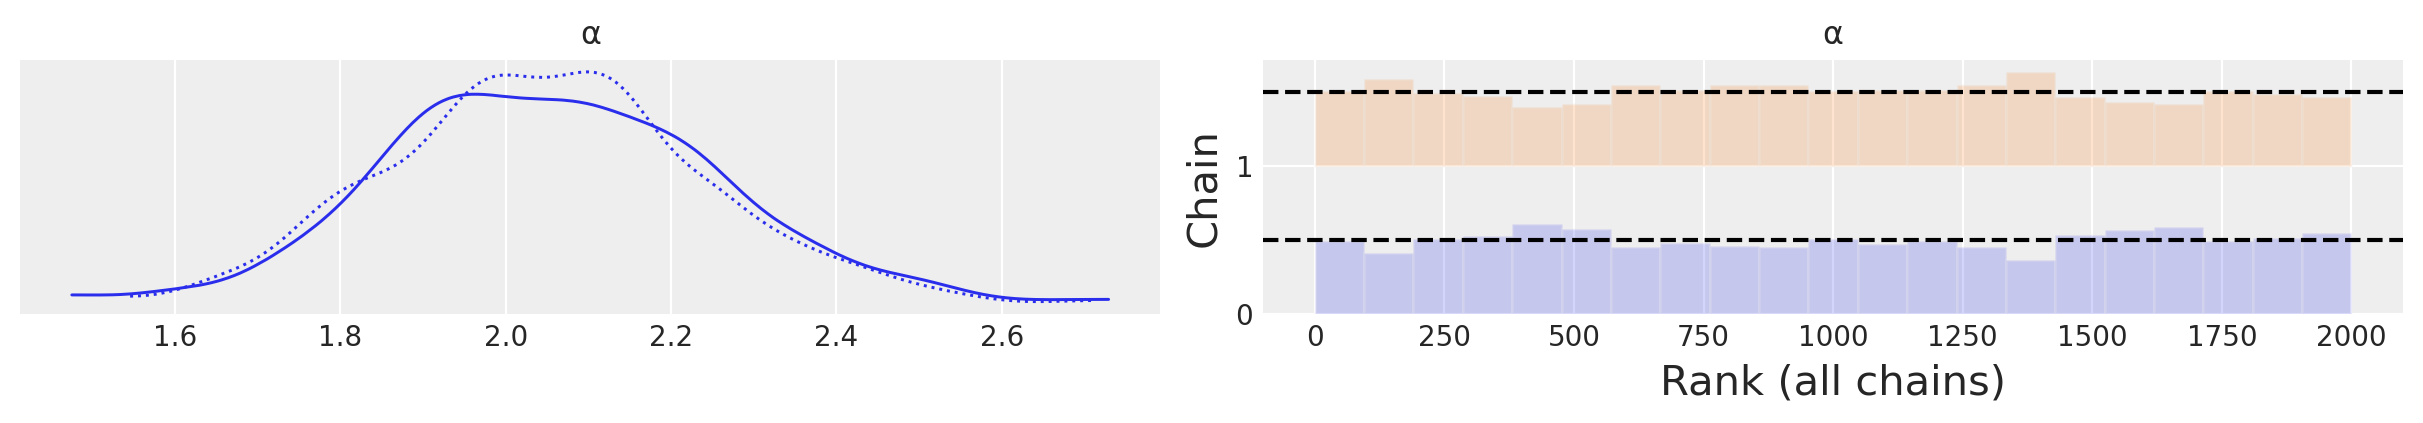

In [17]:
az.plot_trace(idata_bikes, var_names=["α"], kind="rank_bars")

/home/kimh31/miniconda3/envs/cnv/lib/python3.11/site-packages/arviz/plots/ecdfplot.py:298: BehaviourChangeWarning: In future versions, if `eval_points` is not provided, then the ECDF will be evaluated at the unique values of the sample. To keep the current behavior, provide `eval_points` explicitly.
  warnings.warn(


array([<Axes: xlabel='ESS'>, <Axes: xlabel='R-hat'>], dtype=object)

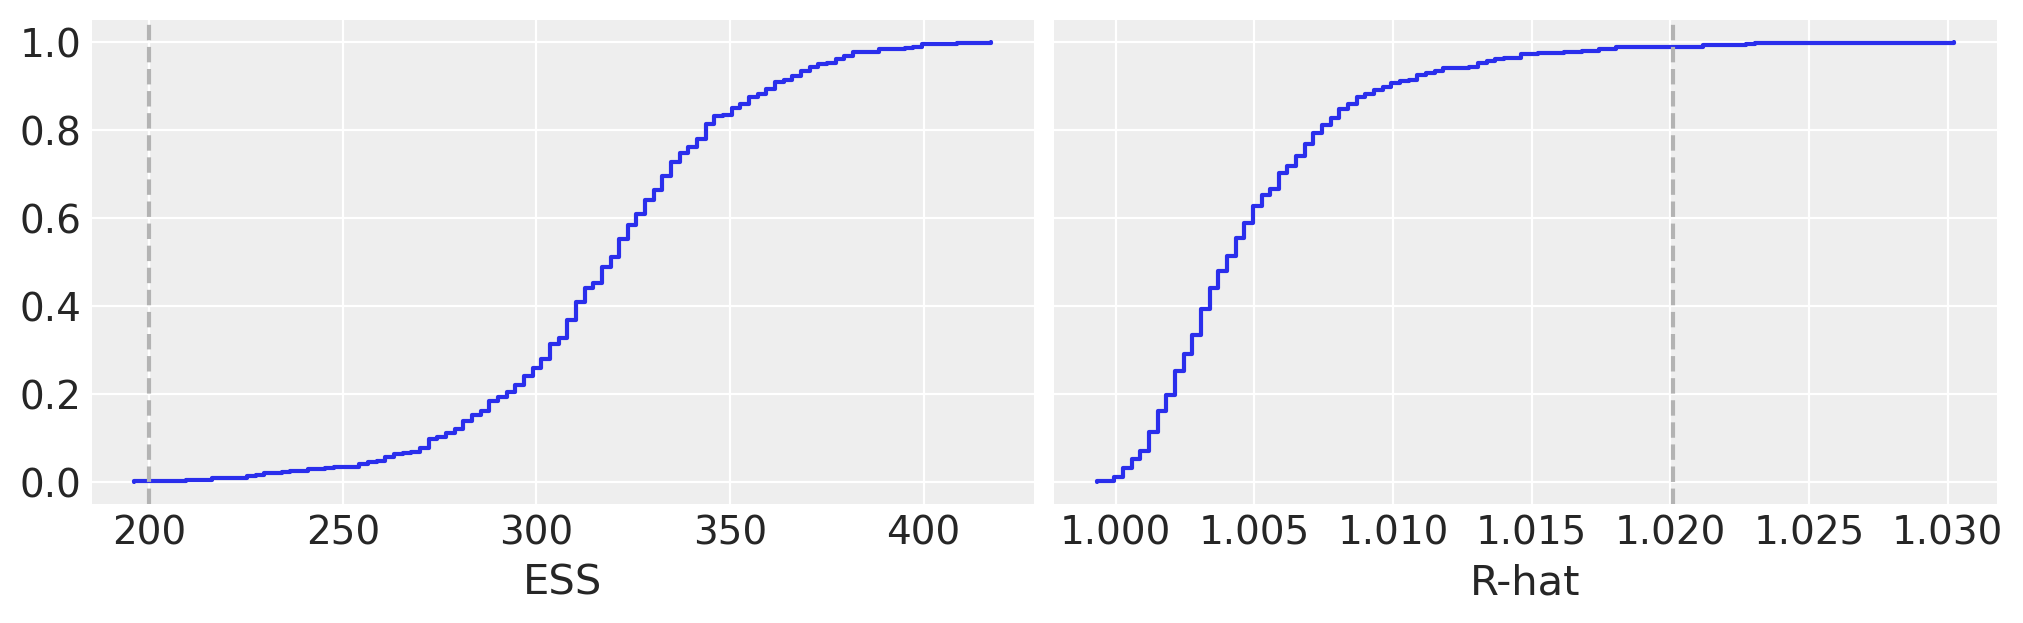

In [19]:
pmb.plot_convergence(idata_bikes, var_name="μ")

array([<Axes: xlabel='hour'>, <Axes: xlabel='temperature'>,
       <Axes: xlabel='humidity'>, <Axes: xlabel='workingday'>],
      dtype=object)

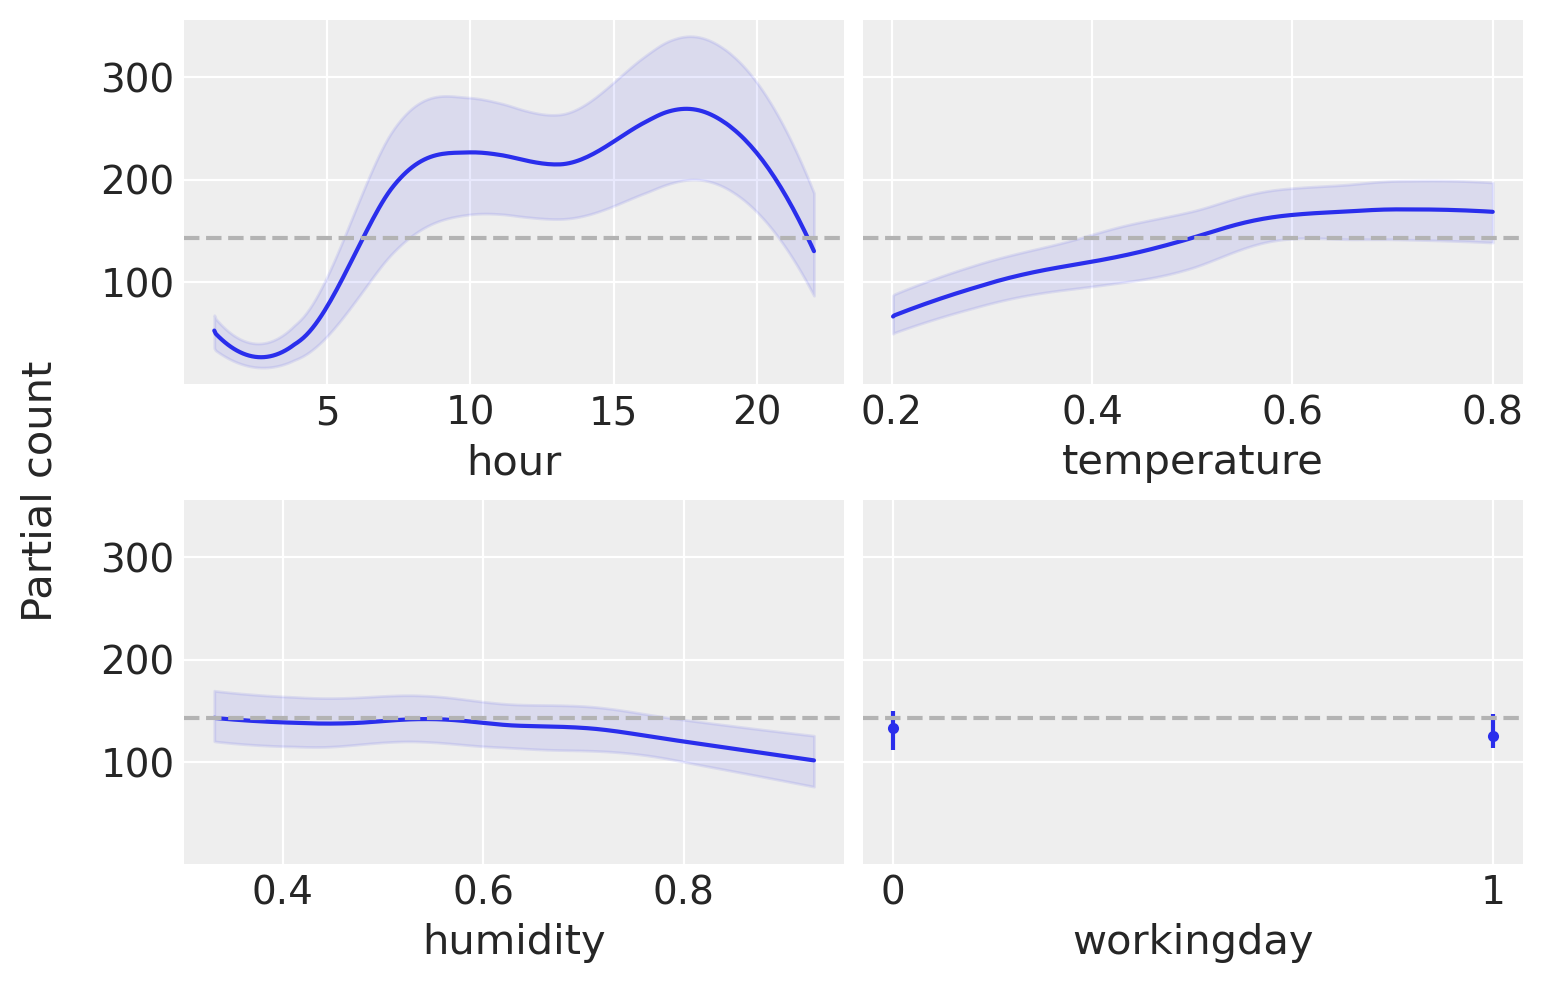

In [20]:
pmb.plot_pdp(μ, X=X, Y=Y, grid=(2, 2), func=np.exp, var_discrete=[3])

<Axes: ylabel='R²'>

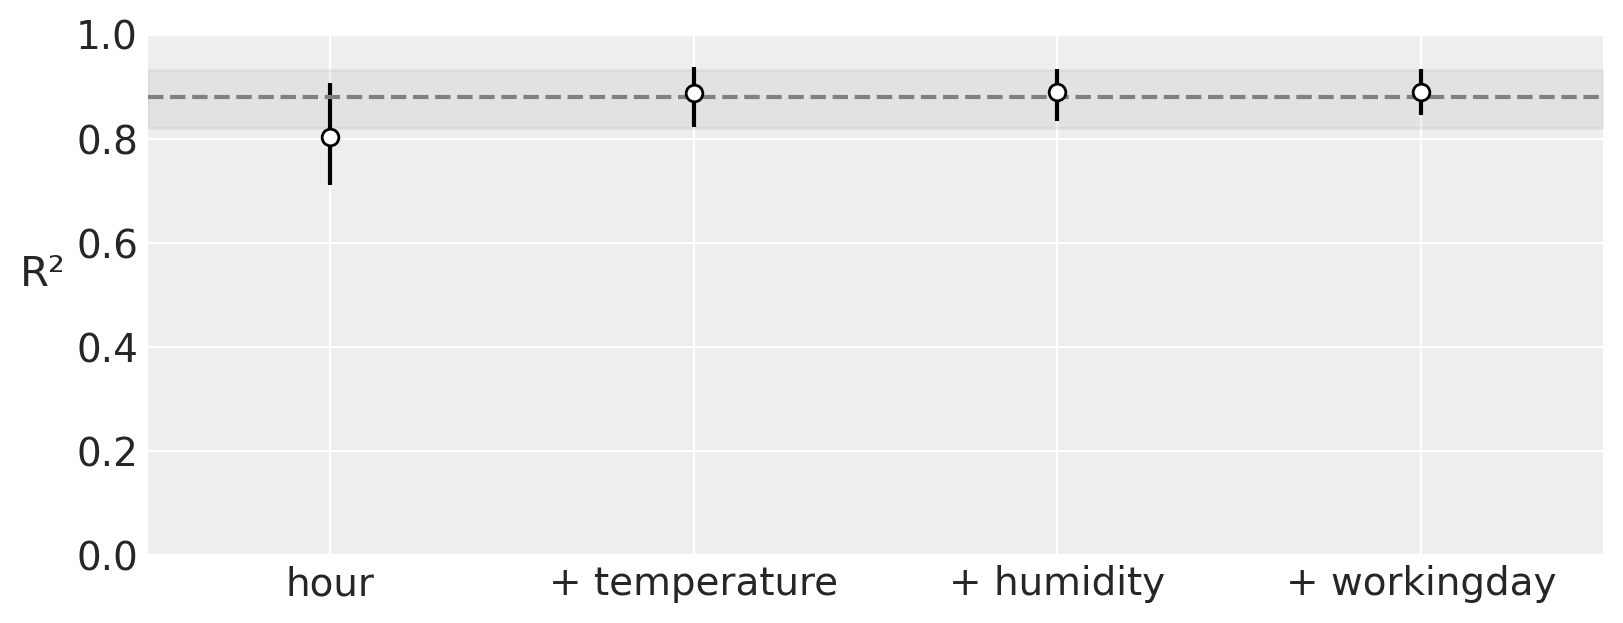

In [21]:
vi_results = pmb.compute_variable_importance(idata_bikes, μ, X)
pmb.plot_variable_importance(vi_results)

## Example 3 (out-of-sample prediction)

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_SEED)

In [23]:
X_train

,hour,temperature,humidity,workingday
202,13,0.46,0.38,1
234,16,0.82,0.59,1
37,2,0.60,0.94,0
158,11,0.62,0.41,1
229,15,0.54,0.68,0
...,...,...,...,...
52,3,0.46,0.72,1
33,2,0.70,0.58,0
74,5,0.60,0.56,1
1,0,0.70,0.79,1


In [24]:
Y_train

202    112
234    258
37     106
158    220
229    554
      ... 
52      14
33      69
74      40
1       28
97      11
Name: count, Length: 278, dtype: int64

In [26]:
# Training BART regression model
with pm.Model() as model_oos_regression:
    X = pm.MutableData("X", X_train)
    Y = Y_train
    α = pm.Exponential("α", 1)
    μ = pmb.BART("μ", X, np.log(Y))
    y = pm.NegativeBinomial("y", mu=pm.math.exp(μ), alpha=α, observed=Y, shape=μ.shape)
    idata_oos_regression = pm.sample(
        cores=1,  # Use single core to avoid multiprocessing issues
        chains=2,
        random_seed=RANDOM_SEED
    )
    posterior_predictive_oos_regression_train = pm.sample_posterior_predictive(
        trace=idata_oos_regression, random_seed=RANDOM_SEED
    )

/home/kimh31/miniconda3/envs/cnv/lib/python3.11/site-packages/pymc/data.py:265: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(
Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [α]
>PGBART: [μ]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 82 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y]


Output()

In [27]:
# Prediction on test set
with model_oos_regression:
    X.set_value(X_test)
    posterior_predictive_oos_regression_test = pm.sample_posterior_predictive(
        trace=idata_oos_regression, random_seed=RANDOM_SEED
    )

Sampling: [y, μ]


Output()

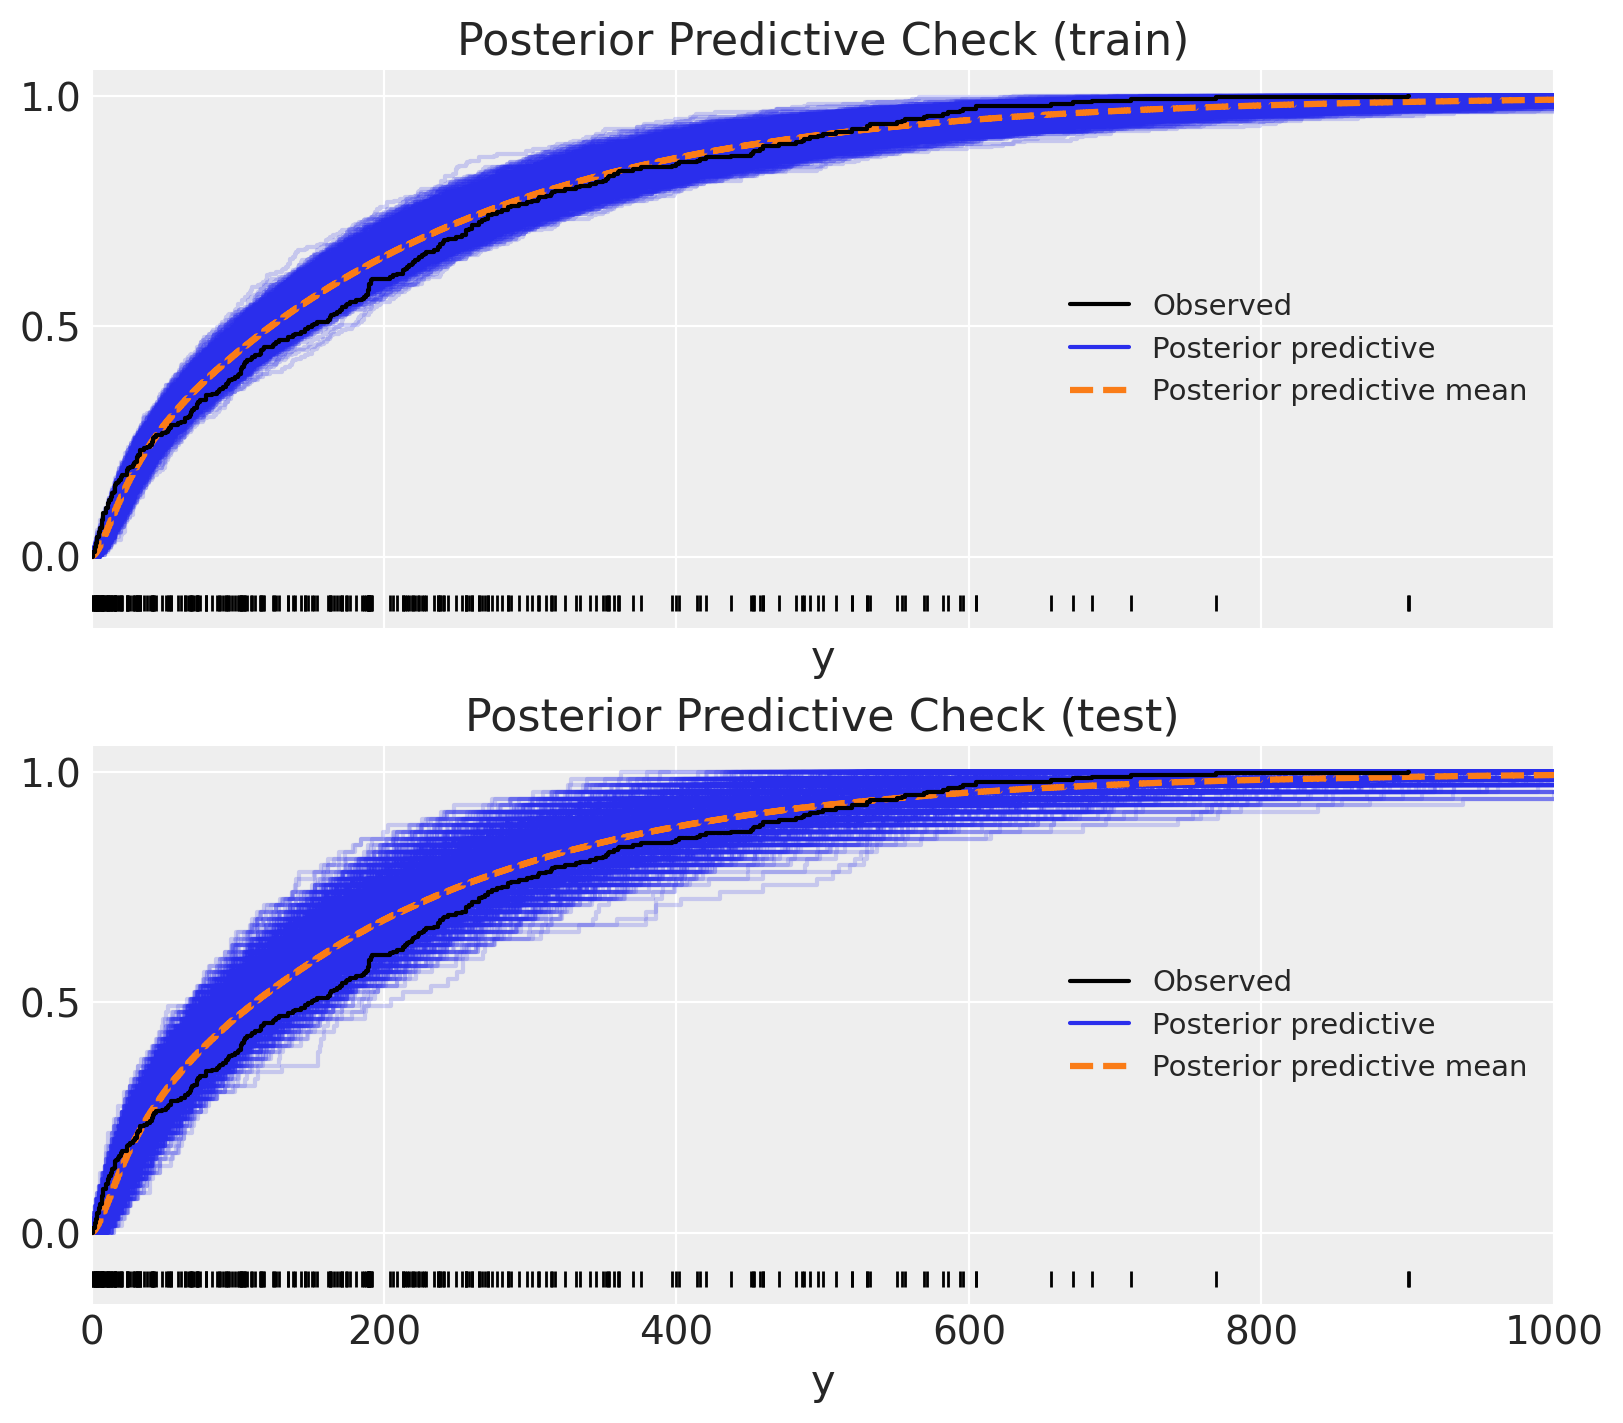

In [28]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(8, 7), sharex=True, sharey=True, layout="constrained"
)

az.plot_ppc(
    data=posterior_predictive_oos_regression_train, kind="cumulative", observed_rug=True, ax=ax[0]
)
ax[0].set(title="Posterior Predictive Check (train)", xlim=(0, 1_000))

az.plot_ppc(
    data=posterior_predictive_oos_regression_test, kind="cumulative", observed_rug=True, ax=ax[1]
)
ax[1].set(title="Posterior Predictive Check (test)", xlim=(0, 1_000));

### Binary classification:

In [ ]:
with pm.Model() as model_oos_classification:
    X = pm.MutableData("X", X_train)
    Y = Y_train  # Y should be binary (0/1)
    
    # BART for the logit of the probability
    μ = pmb.BART("μ", X, Y, m=50)  # No log transformation needed for binary data
    
    # Bernoulli likelihood for binary classification
    # μ represents the logit, so we use logit_p parameter
    y = pm.Bernoulli("y", logit_p=μ, observed=Y)
    
    idata_oos_classification = pm.sample(
        cores=1,  # Use single core to avoid multiprocessing issues
        chains=2,
        random_seed=RANDOM_SEED
    )
    posterior_predictive_oos_classification_train = pm.sample_posterior_predictive(
        trace=idata_oos_classification, random_seed=RANDOM_SEED
    )

with model_oos_classification:
    X.set_value(X_test)
    posterior_predictive_oos_classification_test = pm.sample_posterior_predictive(
        trace=idata_oos_classification, random_seed=RANDOM_SEED
    )

In [ ]:
# Extract predicted probabilities for test set
# Get the logit values from the posterior
logit_samples = idata_oos_classification.posterior["μ"].sel(μ_dim_0=slice(len(X_train), len(X_train) + len(X_test)))

# Convert logit to probabilities using sigmoid function
prob_samples = pm.math.sigmoid(logit_samples).eval()

# Get mean probability for each test sample
mean_probs = prob_samples.mean(axis=(0, 1))

# Make binary predictions (threshold at 0.5)
binary_predictions = (mean_probs > 0.5).astype(int)

print(f"Predicted probabilities shape: {prob_samples.shape}")
print(f"Mean probabilities for first 10 test samples: {mean_probs[:10]}")
print(f"Binary predictions for first 10 test samples: {binary_predictions[:10]}")
print(f"True labels for first 10 test samples: {Y_test.iloc[:10].values}")

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns

# Calculate performance metrics
accuracy = accuracy_score(Y_test, binary_predictions)
roc_auc = roc_auc_score(Y_test, mean_probs)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, binary_predictions))

# Plot confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(Y_test, binary_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Probability histogram by true class
ax2.hist(mean_probs[Y_test == 0], bins=20, alpha=0.7, label='Class 0', color='red')
ax2.hist(mean_probs[Y_test == 1], bins=20, alpha=0.7, label='Class 1', color='blue')
ax2.axvline(0.5, color='black', linestyle='--', label='Threshold')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Frequency')
ax2.set_title('Predicted Probabilities by True Class')
ax2.legend()

plt.tight_layout()
plt.show()